In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score)

# Q1(a) Load the dataset into Python

In [5]:
df = pd.read_csv('/content/loan_approval - loan_approval.csv')

# Q1(b) Display the first 5 rows

In [6]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


# Q1(c) Check the shape of the dataset

In [7]:
df.shape

(2000, 8)

# Q1(d) Display data types of each column

In [8]:
df.dtypes

,0
name,object
city,object
income,int64
credit_score,int64
loan_amount,int64
years_employed,int64
points,int64
loan_approved,bool


# Q2(a) Check for missing values

In [9]:
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


# Q2(b) Handle missing values

No missing values were found in the dataset. Therefore, no missing value treatment was required.

# Q2(c) Identify categorical columns

In [12]:
df.select_dtypes(include='object').columns

Index(['name', 'city'], dtype='object')

# Q3(a) Plot the distribution of target variable

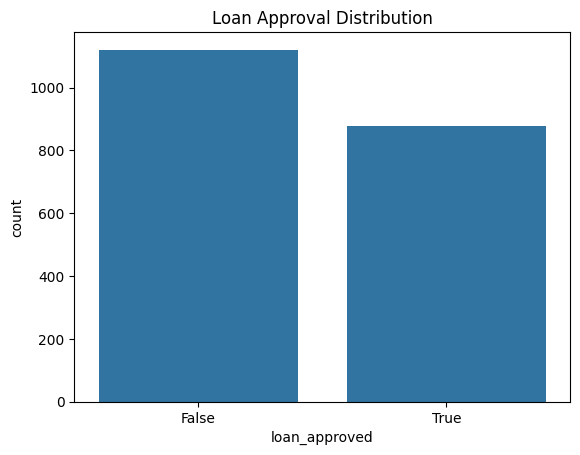

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_approved', data=df)

plt.title("Loan Approval Distribution")

plt.show()

### Interpretation

The countplot represents the distribution of loan approval outcomes in the dataset.

If one class contains significantly more observations than the other, the dataset may be imbalanced. Class imbalance can affect the performance of machine learning models because the model may become biased toward the majority class.

The visualization helps in understanding whether the dataset has a balanced number of approved and rejected loan applications before building the Logistic Regression model.

A balanced dataset generally improves prediction quality and model reliability.

# Q3(b) Relationship between income and loan approval

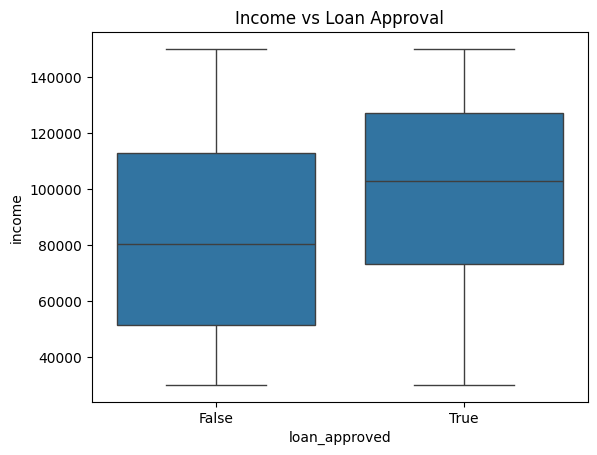

In [15]:
sns.boxplot(x='loan_approved',
            y='income',
            data=df)

plt.title("Income vs Loan Approval")

plt.show()

### Interpretation

The boxplot compares applicant income distributions for approved and rejected loan applications.

The median line inside each box represents the typical income level for each category. The spread of the box indicates income variability among applicants.

If approved applicants tend to have higher median income values, it suggests that income positively influences loan approval decisions. Higher income applicants are generally considered financially stable and capable of repaying loans.

The presence of extreme values outside the whiskers indicates outliers, meaning some applicants have unusually high income levels compared to the majority of the dataset.

# Q3(c) Relationship between years employed and loan approval

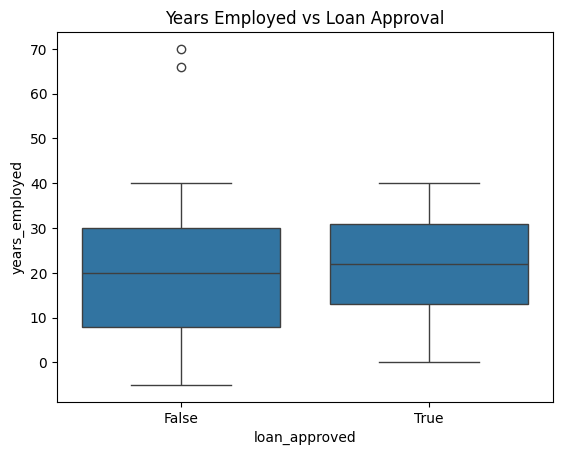

In [16]:
sns.boxplot(x='loan_approved',
            y='years_employed',
            data=df)

plt.title("Years Employed vs Loan Approval")

plt.show()

### Interpretation

The graph analyzes the relationship between years of employment and loan approval status.

Applicants with higher years of employment are generally considered financially stable because long-term employment reflects consistent income and job security.

If the median years of employment for approved loans is higher than rejected loans, it indicates that employment stability positively contributes to loan approval decisions.

The spread of the data also helps identify whether approved applicants have more consistent employment history compared to rejected applicants.

# Q4(a) Detect outliers using boxplot

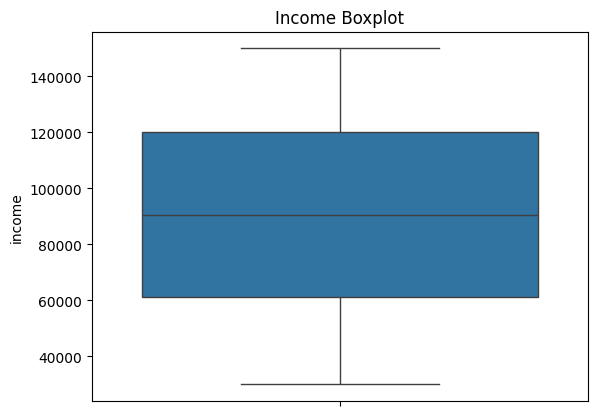

In [17]:
sns.boxplot(df['income'])

plt.title("Income Boxplot")

plt.show()

### Interpretation

The boxplot is used to identify outliers in the income variable.

Outliers are extreme values that lie far away from the majority of observations. These values may occur due to unusual applicant income levels or data entry inconsistencies.

In machine learning, outliers can negatively affect model performance by skewing statistical calculations and influencing prediction boundaries.

The points outside the whiskers of the boxplot indicate potential outliers that may require treatment before model training.

# Q4(b) Treat outliers using IQR method

In [18]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['income'] = df['income'].clip(lower, upper)

### Interpretation

The IQR (Interquartile Range) method was used to treat outliers in the income variable.

This technique caps extreme values within acceptable lower and upper boundaries instead of removing entire records. As a result, important information from the dataset is preserved while reducing the negative influence of abnormal observations.

Outlier treatment improves model stability, reduces bias caused by extreme values, and helps the Logistic Regression algorithm learn more effectively from the data.

# Q5 Prepare dataset for Logistic Regression

In [19]:
df = df.drop(['name', 'city'], axis=1)

### Interpretation

The columns 'name' and 'city' were removed because they are non-numerical text variables that do not directly contribute to prediction.

Machine learning algorithms such as Logistic Regression require numerical input features for model training.

# Convert target variable into numerical format

In [20]:
df['loan_approved'] = df['loan_approved'].astype(int)

### Interpretation

The target variable 'loan_approved' was converted from Boolean values (True/False) into numerical format (1/0).

Machine learning algorithms require numerical target values for classification tasks.

# Q6(a) Separate independent and dependent variables

In [21]:
X = df.drop('loan_approved', axis=1)

y = df['loan_approved']

### Interpretation

The dataset was divided into independent variables (X) and dependent variable (y).

Independent variables are the input features used for prediction, while the dependent variable represents the target outcome that the model aims to predict.

# Q6(b) Split dataset into training and testing sets

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

### Interpretation

The dataset was divided into training and testing datasets.

The training dataset is used to train the Logistic Regression model, while the testing dataset evaluates how well the model performs on unseen data.

This process helps measure the generalization ability of the machine learning model.

# Q7 Apply feature scaling using StandardScaler

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Interpretation

Feature scaling standardizes numerical variables so that all features contribute equally during model training.

Without scaling, variables with large numerical values may dominate the learning process and affect prediction performance.

StandardScaler transforms the data such that each feature has a mean close to 0 and a standard deviation close to 1.

# Q8(a) Train Logistic Regression model

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

### Interpretation

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

The model learns relationships between applicant features such as income, credit score, loan amount, years employed, and points to predict loan approval outcomes.

# Q8(b) Predict loan approval using test dataset

In [25]:
y_pred = model.predict(X_test)

### Interpretation

The trained Logistic Regression model generated predictions for the testing dataset.

The predicted values represent whether a loan application is approved or rejected based on applicant characteristics.

# Q9(a) Generate confusion matrix

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[217   0]
 [  0 183]]


### Interpretation

The confusion matrix summarizes the classification performance of the model.

True Positives represent correctly predicted approved loans, while True Negatives represent correctly predicted rejected loans.

False Positives and False Negatives indicate incorrect predictions made by the model.

The confusion matrix helps evaluate model accuracy and classification errors in detail.

# Calculate Accuracy Score

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


### Interpretation

Accuracy measures the proportion of correctly predicted observations out of the total observations.

A higher accuracy score indicates better predictive performance of the Logistic Regression model.

# Generate Classification Report

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       217
           1       1.00      1.00      1.00       183

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



### Interpretation

The classification report provides detailed performance metrics such as precision, recall, and F1-score.

Precision measures how many predicted positive observations are actually correct.

Recall measures how effectively the model identifies actual positive observations.

F1-score balances both precision and recall to provide an overall performance measure.

# Q10(a) Plot ROC Curve

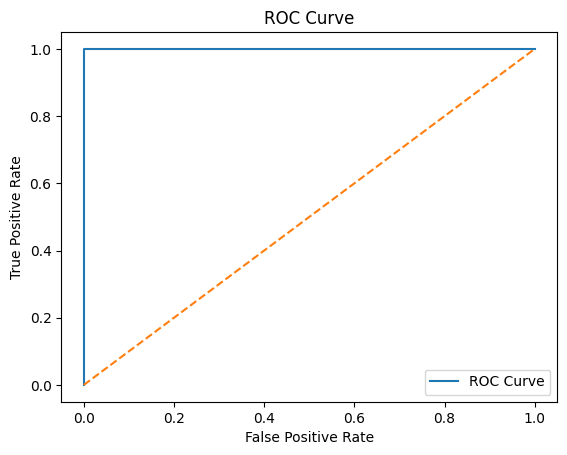

In [29]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label='ROC Curve')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

### Interpretation

The ROC curve evaluates the classification ability of the Logistic Regression model across different threshold values.

A curve closer to the top-left corner indicates stronger classification performance and better discrimination between approved and rejected loan applications.

# Q10(b) Calculate AUC Score

In [30]:
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 1.0


### Interpretation

The AUC score measures the overall ability of the model to distinguish between approved and rejected loan applications.

An AUC value closer to 1 indicates excellent classification performance, while a value near 0.5 represents weak predictive capability.

# Regression Equation

In [31]:
print("Coefficients:", model.coef_)

print("Intercept:", model.intercept_)

Coefficients: [[-0.29090646  0.03820688 -0.06461522 -0.01727141 10.31997443]]
Intercept: [-0.51612253]


### Interpretation

The coefficients represent the influence of each independent variable on loan approval prediction.

Positive coefficients increase the probability of loan approval, while negative coefficients decrease the probability.

Features with larger coefficient magnitudes have stronger impact on model predictions.

# Conclusion

In this project, a Logistic Regression model was successfully developed to predict loan approval status using applicant information such as income, credit score, loan amount, years employed, and points.

The dataset was preprocessed by detecting and treating outliers, removing unnecessary columns, and scaling numerical variables.

Exploratory Data Analysis helped identify important relationships between applicant features and loan approval outcomes.

The Logistic Regression model demonstrated effective classification performance based on evaluation metrics including confusion matrix, accuracy score, classification report, ROC curve, and AUC score.

Overall, this project shows how machine learning techniques can assist financial institutions in automating and improving loan approval decisions.